In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from scipy.ndimage import gaussian_filter
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
path = '/Volumes/Elements/PTM_project/FLN5_proline_METAD/'

1.6 ± 0.0 $\AA$


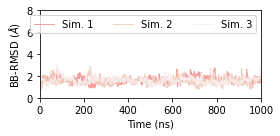

In [2]:
system='FLN5_FL'
ymax = 8

nsims=3

plt.figure(figsize = (4,2))

colors = ['#F49595','#F1CEBE','#F8EDEB']

vals = []

for i in range(1,nsims+1):
    
    dat = np.loadtxt(path+system+'/sim{}/rmsd_BB.xvg'.format(i),skiprows=18)[::50]
    
    rmsd = dat[:,1]*10 # convert to Angstrom
    time = dat[:,0]/1000 # convert to nanoseconds
    
    vals.append(np.mean(rmsd)) # mean 

    plt.plot(time,rmsd,color = colors[i-1],alpha=0.9,linewidth = 1,label = 'Sim. {}'.format(i))
    
plt.legend(ncol=3)
print('{:.1f} ± {:.1f} $\\AA$'.format(np.mean(vals),np.std(vals)/np.sqrt(nsims)))
plt.ylim(0,ymax)
plt.xlim(0,np.max(time))

    
plt.xlabel('Time (ns)')
plt.ylabel('BB-RMSD ($\\AA$)')

plt.tight_layout()
plt.savefig('BB_RMSD_METAD_{}.pdf'.format(system))




